In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

# decision tree for multioutput regression
from sklearn.datasets import make_regression
from sklearn.tree import DecisionTreeRegressor

# KNN for multioutput regression
from sklearn.datasets import make_regression
from sklearn.neighbors import KNeighborsRegressor

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from scipy.io import arff
import csv


In [4]:
data = pd.read_csv('/content/drive/MyDrive/Hasan sir/new_analysis/UCP_Dataset.csv')
#df = (data[0])
#df.head()

In [7]:
type(data)

pandas.core.frame.DataFrame

In [9]:
data['Project_No;Simple Actors;Average Actors;Complex Actors;UAW;Simple UC;Average UC;Complex UC;UUCW;TCF;ECF;Real_P20;Real_Effort_Person_Hours;Sector;Language;Methodology;ApplicationType;DataDonator']

1;1;1;2;9;6;10;15;355;0    81;0    84;398                                                                      5;7970;Manufacturing;Java;;;D1
2;1;2;1;8;4;20;15;445;0    99;0    99;398                                                                                       1;7962;;;;;D1
3;0;0;3;9;1;5;20;355;1     03;0    8;396                                                          75;7935;Banking;C#;;Business Application;D1
4;0;1;2;8;5;10;15;350;0    9;0     91;390                                                   25;7805;Communication;C++;;Real-Time applicati...
5;1;2;1;8;1;10;16;345;0    9;0     91;387                                                   9;7758;Manufacturing;;Waterfall;Real-Time Appl...
                                                                                                                  ...                        
67;0;3;4;18;2;18;18;460;1  05;0    95;290;5800;Government;SQL;;Business Application;D3                                                    NaN
68;1;2

In [13]:
import pandas as pd


df = pd.read_csv('/content/drive/MyDrive/Hasan sir/new_analysis/UCP_Dataset.csv')

# Step 2: Split the data
df = df.split(';')  # Replace 'DataColumn' with your column name

# Step 3: Create new columns
max_values = df['DataColumn'].apply(len).max()
for i in range(max_values):
    df[f'Column_{i+1}'] = df['DataColumn'].apply(lambda x: x[i] if len(x) > i else None)

# Step 4: Save the modified dataset
output_file_path = "path_to_save_modified_dataset.csv"  # Replace with the desired output file path
df.to_csv(output_file_path, index=False)


AttributeError: ignored

In [ ]:
df.describe()

,Project_No;Simple Actors;Average Actors;Complex Actors;UAW;Simple UC;Average UC;Complex UC;UUCW;TCF;ECF;Real_P20;Real_Effort_Person_Hours;Sector;Language;Methodology;ApplicationType;DataDonator
count,60
unique,60
top,5;7970;Manufacturing;Java;;;D1
freq,1


ValueError: ignored

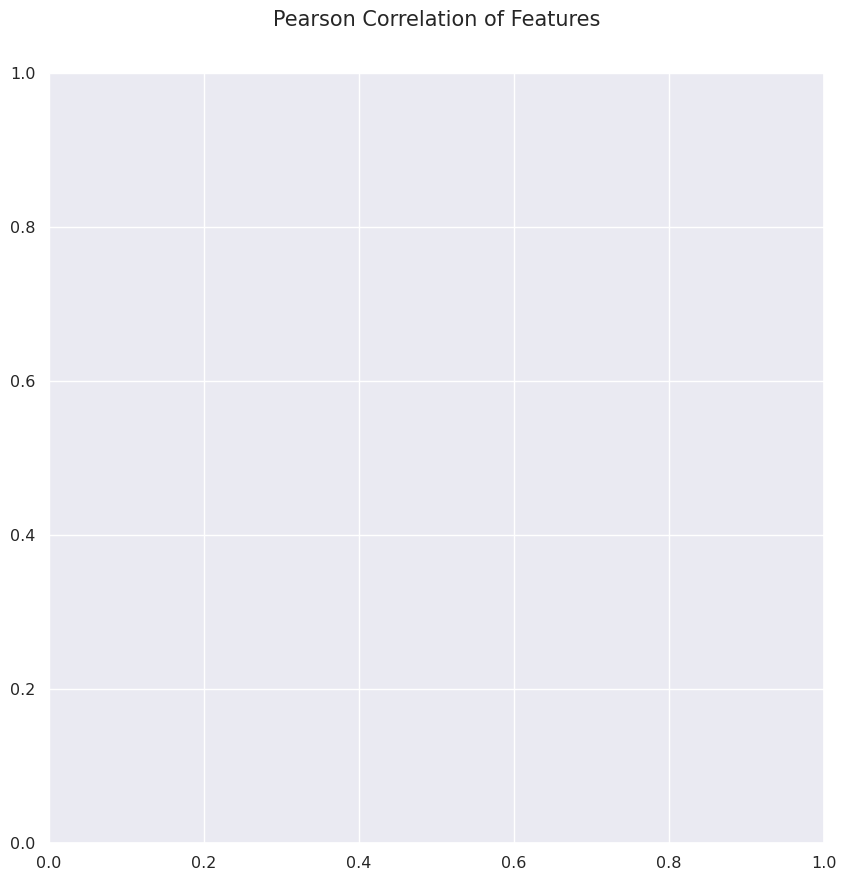

In [ ]:
colormap = plt.cm.viridis
plt.figure(figsize=(10,10))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sns.set(font_scale=1.05)
sns.heatmap(df.astype(float).corr(),linewidths=0.1,vmax=1.0, square=True,cmap=colormap, linecolor='white', annot=True)

In [ ]:
# map features to their absolute correlation values
corr = df.corr().abs()

# set equality (self correlation) as zero
corr[corr == 1] = 0

# of each feature, find the max correlation
# and sort the resulting array in ascending order
corr_cols = corr.max().sort_values(ascending=False)

# display the highly correlated fe
#corr_cols

# display the highly correlated features
display(corr_cols[corr_cols > 0.8])

RawFPcounts    0.985709
AdjFP          0.985709
Effort         0.949967
Output         0.906449
Inquiry        0.840994
File           0.834685
dtype: float64

In [ ]:
#features = [ 'TeamExp', 'ManagerExp', 'YearEnd', 'Length', 'Transactions', 'Entities','PointsNonAdjust', 'Adjustment', 'PointsAjust']

max_corr_features = ['RawFPcounts', 'AdjFP', 'Effort','Output','Inquiry', 'File']

X = df[max_corr_features]
y = df['Effort']

In [ ]:
# Splitting the dataset into the Training set and Test set
X_Train, X_Test, Y_Train, Y_Test = train_test_split(X, y, test_size=0.30, random_state=30)

# ***KNeighborsRegressor***

In [ ]:
#KNeighborsRegressor
neigh = KNeighborsRegressor(n_neighbors=9, weights='uniform')
neigh.fit(X_Train, Y_Train)
predict = neigh.predict(X_Test)
print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict)))
print("Mean Absolute error", mean_absolute_error(Y_Test, predict))

Root mean square:  30.614400408070694
Mean Absolute error 18.258333333333333


In [ ]:
import matplotlib.pyplot as plot
import pandas

In [ ]:
# Splitting the dataset into the Training set and Test set
X_Train, X_Test, Y_Train, Y_Test = train_test_split(X, y, test_size=0.30, random_state=30)

In [ ]:
Y_Train.shape

(16,)

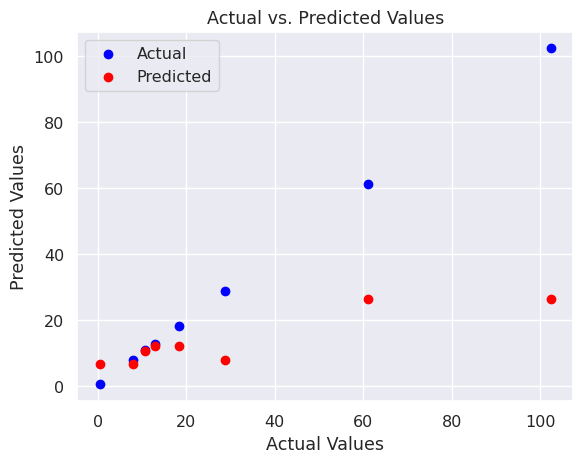

In [ ]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()

# ***LinearRegression***

In [ ]:
regressor = LinearRegression()
regressor.fit(X_Train, Y_Train)
predict = regressor.predict(X_test)
print("Root mean square: ", np.sqrt(mean_squared_error(y_test, predict)))
print("Mean Absolute error", mean_absolute_error(y_test, predict))

NameError: ignored

# ***RandomForestRegressor***

In [ ]:
for i in np.arange(100,1100,100):
    regressor = RandomForestRegressor(n_estimators=i,max_features=5)
    regressor.fit(X_train, y_train)
    predict = regressor.predict(X_test)
    print("Root mean square: ", np.sqrt(mean_squared_error(y_test, predict)))
    print("Mean Absolute error", mean_absolute_error(y_test, predict))

Root mean square:  3416.5495671627536
Mean Absolute error 2611.488
Root mean square:  3518.9835456159776
Mean Absolute error 2601.126
Root mean square:  3479.3736442944246
Mean Absolute error 2593.401066666667
Root mean square:  3564.0608857043953
Mean Absolute error 2637.4804
Root mean square:  3519.7479955872755
Mean Absolute error 2619.7824
Root mean square:  3624.310350528023
Mean Absolute error 2681.4747333333335
Root mean square:  3568.767964948242
Mean Absolute error 2645.1785142857143
Root mean square:  3558.2808335581103
Mean Absolute error 2645.6881
Root mean square:  3567.6521009617086
Mean Absolute error 2640.8578666666667
Root mean square:  3584.4984113957757
Mean Absolute error 2650.56636


# ***SVM***

In [ ]:
parameters = {'kernel':('linear', 'rbf'), 'C':[1,2,3,4,5,6,7,8,9,10, 100, 500], 'gamma':('auto', 'scale')}

svr = SVR()
LinearSVC = GridSearchCV(svr, parameters, cv=3)
LinearSVC.fit(X_train, y_train)
predict = LinearSVC.predict(X_test)
print("Root mean square: ", np.sqrt(mean_squared_error(y_test, predict)))
print("Mean Absolute error", mean_absolute_error(y_test, predict))

Root mean square:  2701.493856525892
Mean Absolute error 2125.4435217369296


# ***lasso***

In [ ]:
from sklearn import linear_model

In [ ]:
clf = linear_model.Lasso(alpha=0.1)

In [ ]:
clf.fit(X_train, y_train)

Lasso(alpha=0.1)

In [ ]:
print(clf.coef_)

[317.01009622 -45.54423086 -41.07567257   2.92714792  47.42829794]


In [ ]:
print(clf.intercept_)

45.9133764011367


In [ ]:
# make a prediction
predict = clf.predict(X_test)
# summarize prediction
print("Root mean square: ", np.sqrt(mean_squared_error(y_test, predict)))
print("Mean Absolute error", mean_absolute_error(y_test, predict))

Root mean square:  2691.0829070183768
Mean Absolute error 2124.2966788713716
